<a href="https://colab.research.google.com/github/Atherizz/ML_2026/blob/main/JS04/tugas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Tugas K-Means

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

url = 'https://raw.githubusercontent.com/Atherizz/ML_2026/main/JS04/Mall_Customers.csv'
df = pd.read_csv(url)

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
# Seleksi Fitur

X = df.iloc[:, 3:]
# y = df.iloc[:, -1]



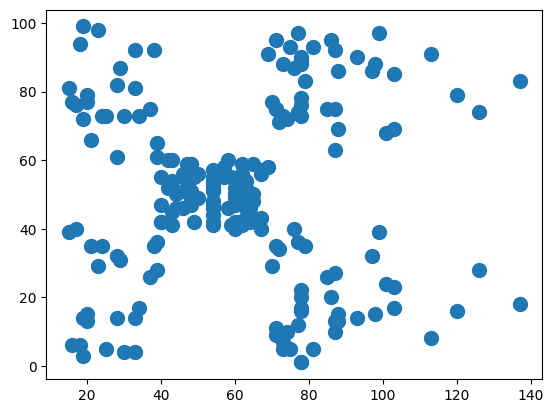

In [ ]:
# Plot Data

plt.scatter(X.iloc[:, 0], X.iloc[:, 1], s = 100)

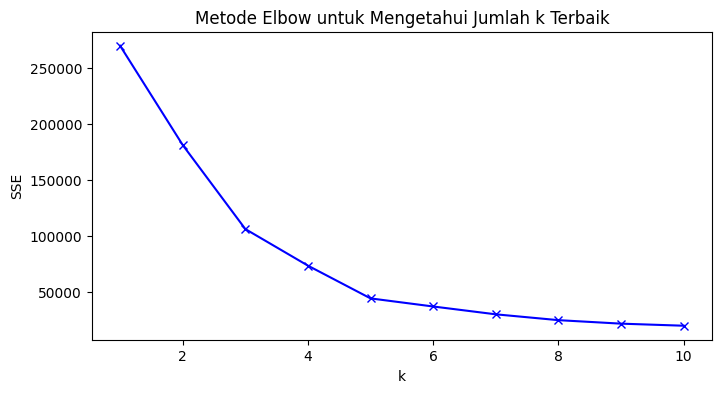

In [ ]:
from sklearn.cluster import KMeans

# List nilai SSE
sse = []

# Cari k terbaik dari 1-10
K = range(1, 11)

# Cek nilai SSE setiap k
for k in K:
    kmeanModel = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeanModel.fit(X)
    sse.append(kmeanModel.inertia_)

# Plot grafik elbow
plt.figure(figsize=(8, 4))
plt.plot(K, sse, "bx-")
plt.xlabel("k")
plt.ylabel("SSE")
plt.title("Metode Elbow untuk Mengetahui Jumlah k Terbaik")
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score

for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X)
    print(f'k={k}; silhouette={silhouette_score(X, labels):.3f}')

k=2; silhouette=0.297
k=3; silhouette=0.468
k=4; silhouette=0.493
k=5; silhouette=0.554
k=6; silhouette=0.540
k=7; silhouette=0.529
k=8; silhouette=0.455
k=9; silhouette=0.456
k=10; silhouette=0.441


## Tugas DBSCAN

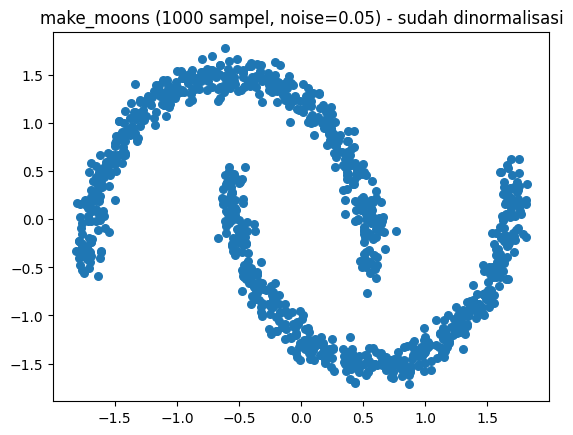

In [1]:
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Buat dataset 2 bulan sabit
X, y_true = make_moons(n_samples=1000, noise=0.05, random_state=0)

# Normalisasi
X = StandardScaler().fit_transform(X)

# Visualisasi awal
plt.scatter(X[:, 0], X[:, 1], s=30)
plt.title("make_moons (1000 sampel, noise=0.05) - sudah dinormalisasi")
plt.show()

In [2]:
import numpy as np
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.2, min_samples=5).fit(X)
labels = db.labels_

n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

Estimated number of clusters: 2
Estimated number of noise points: 0


In [3]:
from sklearn import metrics

print(f"Homogeneity: {metrics.homogeneity_score(y_true, labels):.3f}")
print(f"Completeness: {metrics.completeness_score(y_true, labels):.3f}")
print(f"V-measure: {metrics.v_measure_score(y_true, labels):.3f}")
print(f"Adjusted Rand Index: {metrics.adjusted_rand_score(y_true, labels):.3f}")
print(f"Adjusted Mutual Information: {metrics.adjusted_mutual_info_score(y_true,
labels):.3f}")
print(f"Silhouette Coefficient: {metrics.silhouette_score(X, labels):.3f}")

Homogeneity: 1.000
Completeness: 1.000
V-measure: 1.000
Adjusted Rand Index: 1.000
Adjusted Mutual Information: 1.000
Silhouette Coefficient: 0.392


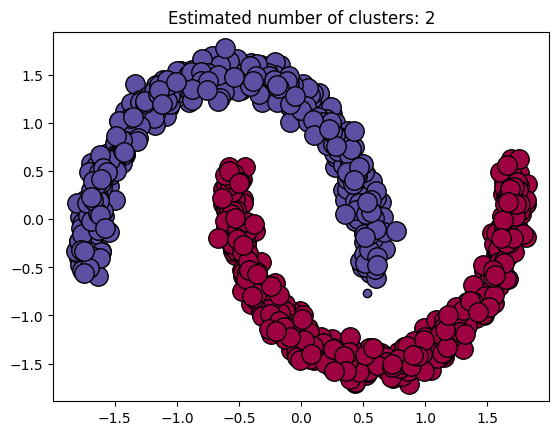

In [4]:
unique_labels = set(labels)
core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True

colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
for k, col in zip(unique_labels, colors):
    if k == -1:
        col = [0, 0, 0, 1]  # noise = hitam

    class_member_mask = labels == k

    xy = X[class_member_mask & core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], "o",
             markerfacecolor=tuple(col), markeredgecolor="k", markersize=14)

    xy = X[class_member_mask & ~core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], "o",
             markerfacecolor=tuple(col), markeredgecolor="k", markersize=6)

plt.title(f"Estimated number of clusters: {n_clusters_}")
plt.show()

In [5]:
eps_values = [0.05, 0.1, 0.3, 0.5]
min_samples_values = [3, 10, 20]

print(f"{'eps':>6} {'min_smp':>8} {'clusters':>9} {'noise':>6} {'ARI':>7} {'Silh':>7}")
print("-" * 50)

for eps in eps_values:
    for ms in min_samples_values:
        db_exp = DBSCAN(eps=eps, min_samples=ms).fit(X)
        lab = db_exp.labels_

        n_c = len(set(lab)) - (1 if -1 in lab else 0)
        n_n = list(lab).count(-1)
        ari = metrics.adjusted_rand_score(y_true, lab)
        sil = metrics.silhouette_score(X, lab) if n_c >= 2 else float('nan')

        print(f"{eps:>6.2f} {ms:>8} {n_c:>9} {n_n:>6} {ari:>7.3f} {sil:>7.3f}")

   eps  min_smp  clusters  noise     ARI    Silh
--------------------------------------------------
  0.05        3        67    197   0.033   0.078
  0.05       10         0   1000   0.000     nan
  0.05       20         0   1000   0.000     nan
  0.10        3         3     18   0.854   0.138
  0.10       10         9     63   0.435   0.184
  0.10       20         6    844   0.010  -0.409
  0.30        3         2      0   1.000   0.392
  0.30       10         2      0   1.000   0.392
  0.30       20         2      0   1.000   0.392
  0.50        3         1      0   0.000     nan
  0.50       10         1      0   0.000     nan
  0.50       20         2      0   0.996   0.393
